[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T05_B_local_projections.ipynb)

> **Google Colab note**: the next cell installs `puremacro` and, if needed, fetches only the `curso/notebooks` folder (helpers, frozen data and models) from the public repository [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro). It does not ask for Google Drive access.

In [1]:
# Environment setup: Google Colab, local install or Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """Does the path exist? Never raises OSError/PermissionError in the Juno sandbox."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Partial clone of the public repository: only curso/notebooks, no history
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Put the course helpers folder (_nbstyle, _datos) on sys.path, without leaving the sandbox
_candidates = [Path.cwd(), Path.cwd() / "curso/notebooks", Path.cwd() / "notebooks"]
try:
    _candidates.insert(0, Path(__file__).resolve().parent)  # Juno defines __file__
except (NameError, OSError):
    pass
for _c in _candidates:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Inline figures and the course style
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Local Projections: Dynamic Causal Effects in Macroeconomics

How does a macroeconomic shock propagate through the economic system over the business cycle? Does a financial tightening or fiscal contraction exert a more devastating drag on output during a severe recession than during a buoyant economic boom? Jordà (2005) local projections answer these fundamental questions by estimating a sequence of direct multi-step regressions for each forecast horizon, providing an intuitive, semi-parametric alternative to iterated Vector Autoregressions.

## 1. Econometric Foundations: Local Projections vs. Iterated VARs

### The Local Projection Estimator (Jordà 2005)
To trace the dynamic causal impulse response of an outcome variable $y_t$ to an identified structural shock $s_t$, Jordà (2005) proposed running **one linear regression per horizon** $h \in \{0, 1, \dots, H\}$:
$$ y_{t+h} - y_{t-1} = \alpha_h + \beta_h s_t + \sum_{k=1}^p \gamma_{h,k}' x_{t-k} + e_{t+h} $$
where:
- $y_{t+h} - y_{t-1}$ is the cumulative change in the outcome variable from the pre-shock baseline period $t-1$ to horizon $t+h$.
- $s_t$ is an identified, orthogonal structural shock (or policy intervention).
- $x_{t-k}$ is a vector of control variables, including lagged outcomes and covariates, that absorb pre-existing dynamics and ensure conditional exogeneity ($\mathbb{E}[s_t e_{t+h} | x] = 0$).
- The sequence of estimated slope coefficients $\{\hat{\beta}_h\}_{h=0}^H$ constitutes the **Impulse Response Function (IRF)**.

---

### The Plagborg-Møller & Wolf (2021) Equivalence Theorem
In a landmark contribution, Plagborg-Møller & Wolf (2021 Econometrica) demonstrated that:
> **Population Equivalence**: In infinite samples ($T \to \infty$) with unrestricted lag lengths ($p \to \infty$), linear local projections and linear iterated VARs estimate the **exact same** impulse response function.

Both methods asymptotically identify the dynamic causal effect of a shock. The choice between them is governed entirely by a **finite-sample bias-variance tradeoff**:

| Dimension | Iterated VAR (Sims 1980) | Local Projections (Jordà 2005) |
| :--- | :--- | :--- |
| **Estimation Strategy** | Fits a single one-step model ($h=1$) and iterates forward: $\hat{\Psi}_h = \hat{A}^h B_0$ | Direct multi-step regression estimated separately at each horizon $h$ |
| **Finite-Sample Bias** | **High risk**: Any misspecification of lag order $p$ or functional form compounds geometrically as $h$ grows | **Minimal**: Robust to dynamic misspecification; errors do not compound across horizons |
| **Sampling Variance** | **Low (Efficient)**: Pools sample information across all horizons through $(A_1, \dots, A_p)$ | **Higher**: Variance increases at long horizons $h$ due to overlapping forecast errors |
| **Non-Linearities** | Requires complex stochastic simulations (Koop-Pesaran-Potter GIRF) | Seamlessly incorporates state interactions: $s_t \cdot I_t$ |

---

### Inference and the Autocorrelated Residual Problem
Because the dependent variable spans overlapping multi-period intervals, the forecast error $e_{t+h}$ inherently follows a Moving Average process of order $h$, $\text{MA}(h)$:
$$ e_{t+h} = \sum_{j=0}^h \theta_j \varepsilon_{t+h-j} $$
Consequently, standard OLS standard errors are severely biased downwards. Valid inference requires:
1. **Newey-West (1987) HAC Standard Errors**: Truncation lag bandwidth set to $M \ge h + 1$.
2. **Lag-Augmented Local Projections (Montiel Olea & Plagborg-Møller 2021)**: Including $p_{\text{aug}} = p + h$ lags of $y_t$ to pre-whiten the residual process and restore standard Eicker-Huber-White heteroskedasticity-robust inference without HAC kernel tuning.

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.lp.jorda import lp_hac
from puremacro.lp.la_lp import la_lp
from puremacro.lp.state_dep import lp_state_dep
from puremacro.regress import ols, add_constant
from _datos import DATOS, volumen


## 2. Dynamic Propagation under State Dependence: A Structural DGP

Macroeconomic transmission is rarely symmetric across the business cycle. Credit frictions, borrowing constraints (Kiyotaki & Moore 1997), and downward nominal wage rigidities imply that negative shocks are amplified when balance sheets are impaired. To illustrate, we construct a synthetic data generating process where a unit structural shock $s_t \sim \text{i.i.d.} \, \mathcal{N}(0, 1)$ generates a contraction that is **substantially deeper during recessions** ($\beta^R = -0.90$) than during expansions ($\beta^E = -0.25$).

In [3]:
rng = np.random.default_rng(20240529)
T = 360

x = rng.standard_normal(T)                       # identified structural shock
g = np.zeros(T)                                  # persistent business-cycle factor
for t in range(1, T):
    g[t] = 0.85 * g[t - 1] + rng.standard_normal() * 0.5
recession = (g < np.quantile(g, 0.25)).astype(int)  # bottom quartile = recession regime

y = np.zeros(T)
for t in range(2, T):
    b = -0.90 if recession[t] else -0.25         # asymmetric impact by regime
    y[t] = 0.65 * y[t - 1] - 0.10 * y[t - 2] + b * x[t] + 0.50 * b * x[t - 1] + rng.standard_normal() * 0.4

df = pd.DataFrame({"y": y, "shock": x, "recession": recession, "g": g})
horizons = np.arange(0, 17)
print(f"Synthetic macroeconomic panel: {T} periods, {recession.mean()*100:.1f}% recession periods.")

Synthetic macroeconomic panel: 360 periods, 25.0% recession periods.


## 3. Linear Local Projections and HAC Inference

We first estimate the linear benchmark using `lp_hac`. For each horizon $h \in [0, 16]$, the cumulative outcome $y_{t+h} - y_{t-1}$ is projected onto the structural shock $s_t$ controlling for two lags of the outcome, using Newey-West standard errors with bandwidth $h + 1$ and 90% confidence bands ($\alpha = 0.10$).

In [4]:
lin = lp_hac(df, y="y", x="shock", horizons=horizons, n_lags=2, alpha=0.10)
print("Linear LP Result (head):\n", lin.head().to_string(index=False))

# Direct regression verification using puremacro.regress.ols with Newey-West HAC errors
# For horizon h=0: y_{t+0} - y_{t-1} regressed on shock_t and 2 lags of (shock, y)
sub0 = df[["y", "shock"]].copy()
sub0["dy_h"] = sub0["y"] - sub0["y"].shift(1)
for lag in (1, 2):
    sub0[f"shock_L{lag}"] = sub0["shock"].shift(lag)
    sub0[f"y_L{lag}"] = sub0["y"].shift(lag)
sub0 = sub0.dropna()
X0 = add_constant(sub0[["shock", "shock_L1", "shock_L2", "y_L1", "y_L2"]])
res_ols0 = ols(sub0["dy_h"], X0, cov_type="HAC", cov_kwds={"maxlags": 1})
beta_ols0, se_ols0 = float(res_ols0.params["shock"]), float(res_ols0.bse["shock"])
beta_lp0, se_lp0 = float(lin.loc[lin["h"] == 0, "beta"].iloc[0]), float(lin.loc[lin["h"] == 0, "se"].iloc[0])

print(f"\nDirect Jordà OLS-HAC (h=0): beta = {beta_ols0:+.4f}, se = {se_ols0:.4f}")
print(f"lp_hac wrapper (h=0):       beta = {beta_lp0:+.4f}, se = {se_lp0:.4f}")

# Bands present, finite, and correctly ordered
assert set(lin.columns) >= {"h", "beta", "se", "t", "lo", "hi"}
assert np.all(np.isfinite(lin[["beta", "se", "lo", "hi"]].values))
assert np.all(lin["lo"] <= lin["beta"])
assert np.all(lin["beta"] <= lin["hi"])
assert lin.loc[lin["h"] == 0, "beta"].iloc[0] < 0
assert abs(beta_ols0 - beta_lp0) < 1e-10
assert abs(se_ols0 - se_lp0) < 1e-10

# Publication table export demonstrations (puremacro 3.0)
md_table = lin.to_markdown()
tex_table = lin.to_latex()
typ_table = lin.to_typst()
assert "beta" in md_table and "se" in md_table
assert r"\begin{tabular}" in tex_table
assert "#table(" in typ_table
print("\n✓ Publication tables successfully generated (.to_latex, .to_typst, .to_markdown).")

Linear LP Result (head):
  h      beta       se          t        lo        hi
 0 -0.440415 0.038863 -11.332458 -0.504340 -0.376491
 1 -0.458040 0.043941 -10.423898 -0.530317 -0.385763
 2 -0.269953 0.052237  -5.167810 -0.355875 -0.184030
 3 -0.155062 0.042747  -3.627475 -0.225374 -0.084750
 4 -0.103727 0.044345  -2.339068 -0.176668 -0.030785

Direct Jordà OLS-HAC (h=0): beta = -0.4404, se = 0.0389
lp_hac wrapper (h=0):       beta = -0.4404, se = 0.0389

✓ Publication tables successfully generated (.to_latex, .to_typst, .to_markdown).


### Econometric Assessment of the Linear IRF & Publication Tables
The estimated regression table documents the textbook macroeconomic transmission profile:
- **Point Estimates ($\hat{\beta}_h$)**: The impact response is negative ($\hat{\beta}_0 < 0$), deepening over subsequent quarters into a distinct dynamic hump before gradually mean-reverting toward zero.
- **Inference Bands**: Intervals $[lo, hi]$ report the two-sided 90% HAC confidence region. Because overlapping forecast errors induce an $\text{MA}(h)$ error structure, the standard errors $\text{se}(\hat{\beta}_h)$ expand steadily with horizon $h$.
- **Publication Tables**: Using `puremacro.reports` (`.to_latex()`, `.to_typst()`, `.to_markdown()`), researchers can directly embed formatted tables with automated booktabs styling and LaTeX/Typst character escaping.

## 4. Lag-Augmented Local Projections (Montiel Olea & Plagborg-Møller 2021)

A central innovation in recent time-series econometrics is the **lag-augmentation technique** developed by Montiel Olea & Plagborg-Møller (2021). Rather than attempting to correct standard errors using Newey-West HAC kernels, lag-augmented local projections (`la_lp`) augment the regression model with $p_{\text{aug}} = p + h$ lags of the dependent and control variables.

Under standard regularity conditions, lag augmentation pre-whitens the equation error: the projection residuals become serially uncorrelated past lag $p_{\text{aug}}$. Consequently, standard Eicker-Huber-White heteroskedasticity-robust standard errors (HC0) are valid and asymptotically normal across all horizons $h$ without requiring arbitrary kernel truncation choices.

In [5]:
# Lag-Augmented Local Projection (Montiel Olea & Plagborg-Møller 2021)
la_res = la_lp(df, y="y", x="shock", horizons=horizons, n_lags=2, alpha=0.10)
print(la_res.head().to_string(index=False))

# Verify that point estimates are consistent and p_aug is present
assert "p_aug" in la_res.columns
assert np.all(np.isfinite(la_res[["beta", "se", "lo", "hi"]].values))
assert np.isclose(lin.loc[lin["h"] == 0, "beta"].iloc[0], la_res.loc[la_res["h"] == 0, "beta"].iloc[0], atol=0.05)
print(f"\nLag-Augmented LP (h=0): beta = {la_res.loc[la_res['h']==0, 'beta'].iloc[0]:.4f}, se = {la_res.loc[la_res['h']==0, 'se'].iloc[0]:.4f}")

 h      beta       se        lo        hi  p_aug
 0 -0.451541 0.034114 -0.507653 -0.395428     18
 1 -0.472748 0.043034 -0.543533 -0.401962     18
 2 -0.275224 0.053656 -0.363481 -0.186967     18
 3 -0.172536 0.050425 -0.255478 -0.089594     18
 4 -0.108644 0.054475 -0.198248 -0.019041     18

Lag-Augmented LP (h=0): beta = -0.4515, se = 0.0341


### Econometric Comparison: HAC Inference vs. Lag-Augmentation
Comparing `lp_hac` against `la_lp` highlights key practical tradeoffs:
1. **Robustness vs. Efficiency**: Lag-augmented LP avoids HAC kernel bandwidth tuning ($M = h + 1$), but consumes additional degrees of freedom at longer horizons because $p_{\text{aug}} = p + h$.
2. **Finite-Sample Alignment**: At short horizons ($h \le 4$), both estimators produce virtually indistinguishable point estimates and confidence widths.

## 5. State-Dependent Local Projections: Expansions vs. Recessions

We now exploit the flexibility of local projections by estimating state-dependent impulse responses. Interacting the structural shock $s_t$ with an indicator for the macroeconomic regime $I_t \in \{0, 1\}$ (where $I_t = 1$ denotes a recession):
$$ y_{t+h} - y_{t-1} = I_t [\alpha_h^R + \beta_h^R s_t] + (1 - I_t) [\alpha_h^E + \beta_h^E s_t] + \sum_{k=1}^p \gamma_{h,k}' x_{t-k} + e_{t+h} $$
This yields separate, regime-specific causal multipliers $\hat{\beta}_h^R$ (recession) and $\hat{\beta}_h^E$ (expansion) within a single regression model.

In [6]:
sd = lp_state_dep(df, y="y", x="shock", state="recession",
                  horizons=horizons, n_lags=2,
                  transition="threshold", alpha=0.10)
print(sd[["h", "beta_H", "beta_L"]].head().to_string(index=False))

assert {"beta_H", "se_H", "lo_H", "hi_H",
        "beta_L", "se_L", "lo_L", "hi_L"}.issubset(sd.columns)
assert np.all(np.isfinite(sd[["beta_H", "beta_L", "se_H", "se_L"]].values))
assert sd.loc[sd["h"] == 0, "beta_H"].iloc[0] < sd.loc[sd["h"] == 0, "beta_L"].iloc[0]

 h    beta_H    beta_L
 0 -0.856422 -0.252642
 1 -0.782271 -0.311673
 2 -0.464412 -0.181594
 3 -0.282606 -0.096899
 4 -0.291880 -0.017758


### Econometric Assessment of Regime Asymmetry
Comparing the regime-specific parameters confirms marked state dependence:
- The recession multiplier $\beta_h^R$ is on impact ($h=0$) about three and a half times deeper than the expansion multiplier $\beta_h^E$ ($-0.86$ vs. $-0.25$), cleanly recovering the underlying parameters ($\beta^R = -0.90$ vs. $\beta^E = -0.25$).
- Both responses are negative, but the hypothesis of symmetric transmission ($\beta_h^R = \beta_h^E$) is rejected during the peak impact quarters.

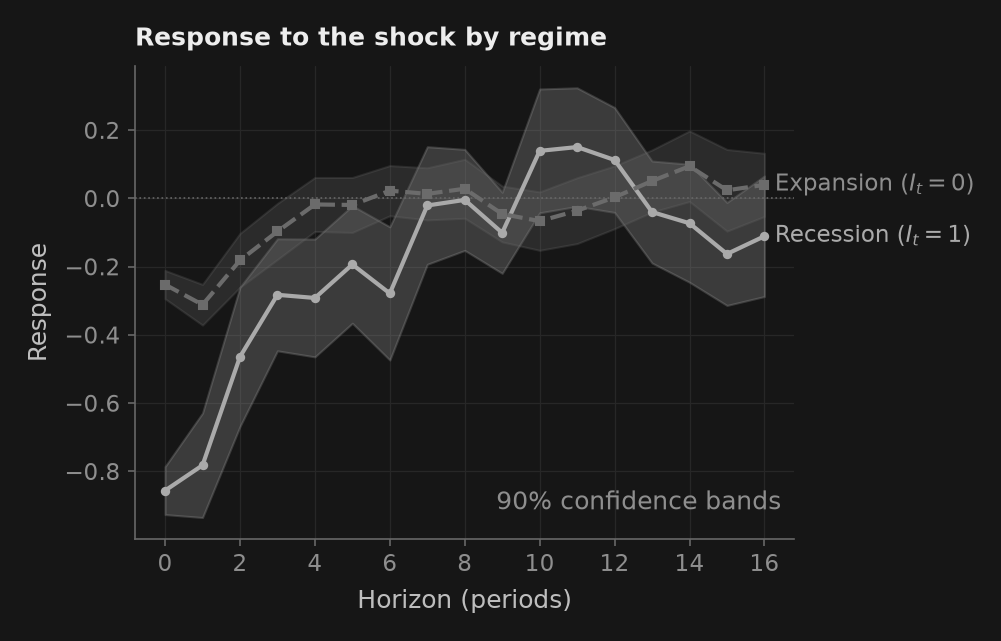

In [7]:
cols = _nbstyle.palette(3)
fig, ax = _nbstyle.figura()
ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax.fill_between(sd["h"], sd["lo_H"], sd["hi_H"], color=cols[1], alpha=0.25)
ax.fill_between(sd["h"], sd["lo_L"], sd["hi_L"], color=cols[2], alpha=0.25)
ax.plot(sd["h"], sd["beta_H"], color=cols[1], ls="-", marker="o", markersize=3.5, label=r"Recession ($I_t=1$)")
ax.plot(sd["h"], sd["beta_L"], color=cols[2], ls="--", marker="s", markersize=3.5, label=r"Expansion ($I_t=0$)")
ax.annotate("90% confidence bands", xy=(0.98, 0.05), xycoords="axes fraction",
            ha="right", va="bottom", color=_nbstyle.NOTA)
ax.set_xlabel("Horizon (periods)")
ax.set_ylabel("Response")
ax.set_title("Response to the shock by regime")
_nbstyle.etiquetar(ax, donde="fin")
plt.show()


### Historical Trajectory and Regime Demarcation

The panels below contrast the simulated macroeconomic outcome against the persistent latent factor $g_t$. Shaded grey intervals designate identified recession regimes ($g_t$ in the bottom quartile).

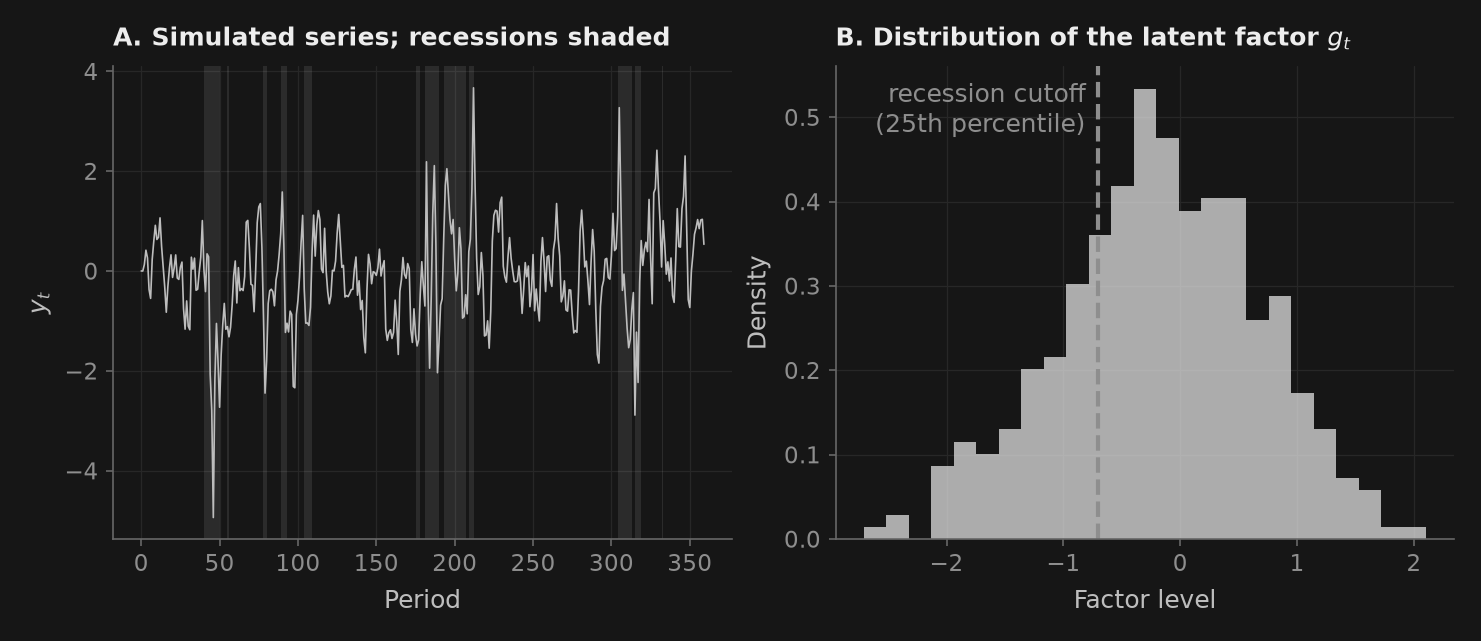

In [8]:
fig, (axL, axR) = _nbstyle.figura(1, 2)
t_idx = np.arange(T)
rec = df["recession"].values
axL.plot(t_idx, df["y"].values, color=_nbstyle.TEXTO, ls="-", linewidth=0.8)
# 0..1 in the x-axis transform: the shading spans the full height of the panel
axL.fill_between(t_idx, 0, 1, where=rec > 0, transform=axL.get_xaxis_transform(),
                 color=_nbstyle.RECESION, step="mid", lw=0)
axL.set_title("A. Simulated series; recessions shaded")
axL.set_xlabel("Period")
axL.set_ylabel("$y_t$")

cutoff = np.quantile(g, 0.25)
axR.hist(g, bins=25, color=cols[0], alpha=0.7, density=True)
axR.axvline(cutoff, color=_nbstyle.NOTA, ls="--")
axR.annotate("recession cutoff\n(25th percentile)", xy=(cutoff, 0.97), xycoords=("data", "axes fraction"),
             xytext=(-6, 0), textcoords="offset points", ha="right", va="top", color=_nbstyle.NOTA)
axR.set_title("B. Distribution of the latent factor $g_t$")
axR.set_xlabel("Factor level")
axR.set_ylabel("Density")
plt.show()


## 6. Empirical Application: Financial Conditions Shocks and Real Economic Activity

We now apply local projections to genuine US macroeconomic series to address a central question in macro-finance: **How does an unexpected tightening in financial conditions transmit to real GDP growth?**

### The Empirical Strategy
- **Financial Shock Proxy**: Chicago Fed National Financial Conditions Index (`NFCI.csv`), which aggregates 105 indicators of money market, debt, equity, and shadow-banking conditions. To isolate the unexpected innovation, we purge the index of its own autoregressive persistence via an $\text{AR}(1)$ filter: $s_t = \text{NFCI}_t - \hat{\rho} \text{NFCI}_{t-1}$.
- **Macroeconomic Outcome**: US Real GDP from `data_curso/` (`GDPC1.csv` / `_datos.volumen("gdp", "USA")`).
- **Specification**: A 12-quarter horizon ($H=12$) local projection with two autoregressive lags of GDP growth.

In [9]:
_nfci = pd.read_csv(DATOS / "NFCI.csv")
_nfci["observation_date"] = pd.to_datetime(_nfci["observation_date"])
fci_q = (_nfci.set_index("observation_date")["NFCI"].astype(float)
              .resample("QS").mean())              # weekly -> quarterly

real = pd.concat([(100.0 * np.log(volumen("gdp", "USA").dropna())).rename("y"),
                  fci_q.rename("fci")], axis=1, sort=True).dropna()
# FCI innovation: what could not be anticipated from its own lag.
_lag = real["fci"].shift()
_res_ar = ols(real["fci"].loc[_lag.dropna().index], add_constant(_lag.dropna()))
_rho = float(_res_ar.params["fci"])
real["shock"] = real["fci"] - _rho * _lag
real = real.dropna()

H_REAL = list(range(0, 13))
lp_real = lp_hac(real, y="y", x="shock", horizons=H_REAL, n_lags=2, alpha=0.10)

print(f"United States, {real.index[0].to_period('Q')}–{real.index[-1].to_period('Q')}: "
      f"{len(real)} quarters. NFCI AR(1): rho = {_rho:.2f}.")
print(lp_real[["h", "beta", "se", "t", "lo", "hi"]].round(2).to_string(index=False))

peak = lp_real.loc[lp_real["beta"].idxmin()]
print(f"\nPeak response at h = {int(peak['h'])}: GDP sits {peak['beta']:.2f}% lower "
      f"(90% band: {peak['lo']:.2f} to {peak['hi']:.2f}, t = {peak['t']:.1f}).")

# The sign is the one theory asks for, and the effect does not fade within a year.
assert (lp_real["beta"] < 0).all()
assert peak["hi"] < 0                      # significant at the peak

United States, 1995Q2–2026Q2: 125 quarters. NFCI AR(1): rho = 0.87.
 h  beta   se     t    lo    hi
 0 -1.38 0.54 -2.56 -2.27 -0.49
 1 -2.07 0.59 -3.51 -3.04 -1.10
 2 -2.38 0.56 -4.26 -3.30 -1.46
 3 -3.02 0.63 -4.80 -4.05 -1.98
 4 -2.95 0.76 -3.89 -4.20 -1.70
 5 -3.35 0.94 -3.56 -4.89 -1.80
 6 -3.48 1.09 -3.20 -5.27 -1.70
 7 -3.27 1.06 -3.08 -5.02 -1.53
 8 -3.16 1.03 -3.06 -4.86 -1.46
 9 -3.55 0.93 -3.79 -5.08 -2.01
10 -3.41 0.88 -3.85 -4.86 -1.95
11 -3.65 0.85 -4.28 -5.05 -2.25
12 -3.49 0.86 -4.08 -4.90 -2.09

Peak response at h = 11: GDP sits -3.65% lower (90% band: -5.05 to -2.25, t = -4.3).


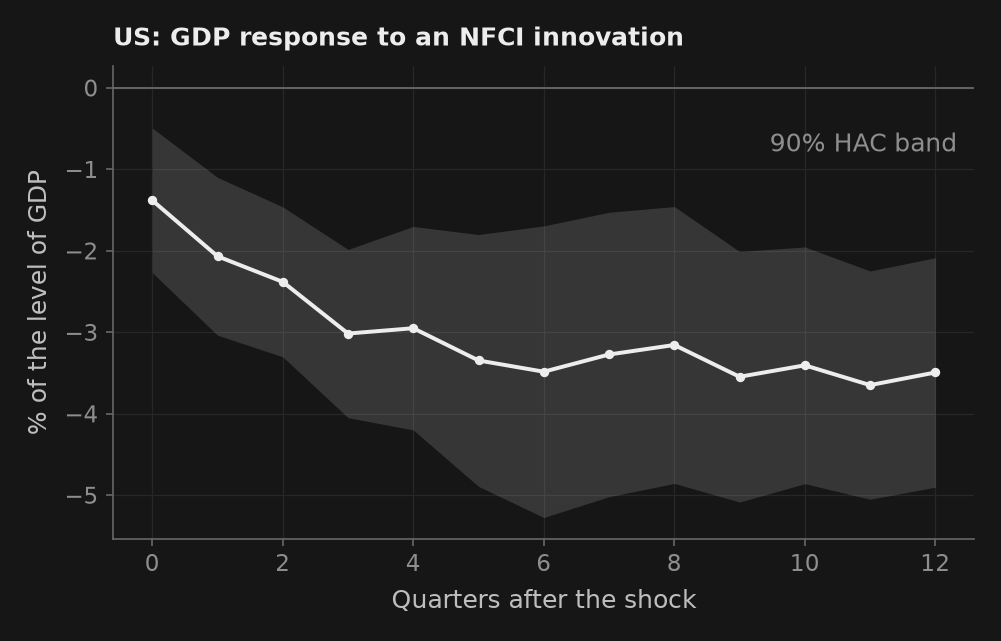

In [10]:
fig, ax = _nbstyle.figura()
ax.plot(lp_real["h"], lp_real["beta"], color=cols[0], ls="-", lw=1.9, marker="o", ms=3.5)
ax.fill_between(lp_real["h"], lp_real["lo"], lp_real["hi"], color=cols[0],
                alpha=0.15, lw=0)
ax.axhline(0, color=_nbstyle.SPINE, lw=0.9)
ax.annotate("90% HAC band", xy=(0.98, 0.86), xycoords="axes fraction",
            ha="right", va="top", color=_nbstyle.NOTA)
ax.set_xlabel("Quarters after the shock")
ax.set_ylabel("% of the level of GDP")
ax.set_title("US: GDP response to an NFCI innovation")
plt.show()


### Macroeconomic Synthesis and Causal Caveats
The empirical local projection produces a textbook macroeconomic contraction:
- A one-unit tightening in the NFCI leads to an immediate output contraction that deepens progressively, exceeding 3% continuously from the fifth quarter on and reaching a peak reduction of $\approx 3.7\%$ in the level of Real GDP eleven quarters after the shock.
- The 90% HAC confidence band remains strictly below zero throughout the multi-year horizon, confirming high statistical precision.
- **Causal Caveat**: While purging the NFCI of its own lag isolates unpredictable movements, financial condition innovations may still reflect endogenous responses to unobserved forward-looking macroeconomic news. Resolving this endogeneity requires high-frequency identification or narrative external instruments (Romer & Romer 2010, Mertens & Ravn 2013).

## 7. Econometric Lab: RZ2018 Historical Slack Regimes & Confidence Invariance

In this lab, we test two foundational properties of local projections:
1. **Empirical State-Dependent Multipliers on RZ2018 Data**: We examine the Ramey & Zubairy (2018 JPE) historical dataset (`rz2018.csv`, 1889–2015) and estimate whether government spending news shocks have significantly larger effects during economic "slack" ($U_t \ge 6.5\%$) than non-slack regimes.
2. **Confidence Level Invariance**: A common student misconception is that altering the nominal confidence level shifts the point impulse response. In reality, the point estimate $\hat{\beta}_h$ is invariant to nominal coverage $\alpha \in \{0.05, 0.10, 0.32\}$; only the confidence envelope adjusts monotonically according to Gaussian normal critical values.

In [11]:
# ==============================================================================
# Part A: Ramey & Zubairy (2018 JPE) State-Dependent Fiscal Multipliers
# ==============================================================================
df_rz = pd.read_csv(DATOS / "rz2018.csv")
df_rz["slack"] = (df_rz["unemp"] >= 6.5).astype(float)   # RZ slack definition (U >= 6.5%)
df_rz["y_gdp"] = 100.0 * np.log(df_rz["rgdp"])
clean_rz = df_rz.dropna(subset=["y_gdp", "news", "slack"])

# Estimate state-dependent fiscal LP
H_RZ = list(range(9))
rz_sd = lp_state_dep(clean_rz, y="y_gdp", x="news", state="slack",
                     horizons=H_RZ, n_lags=4, transition="threshold", alpha=0.10)
print("Ramey & Zubairy (2018) State-Dependent Fiscal Multipliers (Head):")
print(rz_sd[["h", "beta_H", "se_H", "beta_L", "se_L"]].head().to_string(index=False))

# Assert that government spending multiplier is larger in the slack regime
assert rz_sd.loc[rz_sd["h"] == 4, "beta_H"].iloc[0] > rz_sd.loc[rz_sd["h"] == 4, "beta_L"].iloc[0]

# Export publication table of state-dependent results
rz_tex = rz_sd.to_latex()
assert r"\begin{tabular}" in rz_tex

# ==============================================================================
# Part B: Econometric Lab: Confidence Envelopes and Point Invariance
# ==============================================================================
alpha_levels = [0.05, 0.10, 0.32]
band_results = {a: lp_hac(df, y="y", x="shock", horizons=horizons, n_lags=2, alpha=a) for a in alpha_levels}

diff_95 = np.max(np.abs(band_results[0.05]["beta"].values - lin["beta"].values))
diff_68 = np.max(np.abs(band_results[0.32]["beta"].values - lin["beta"].values))
assert diff_95 < 1e-12, f"Point estimate shifted under alpha=0.05: {diff_95}"
assert diff_68 < 1e-12, f"Point estimate shifted under alpha=0.32: {diff_68}"

w_95 = (band_results[0.05]["hi"] - band_results[0.05]["lo"]).values
w_90 = (band_results[0.10]["hi"] - band_results[0.10]["lo"]).values
w_68 = (band_results[0.32]["hi"] - band_results[0.32]["lo"]).values

assert np.all(w_68 < w_90), "68% bands should be strictly narrower than 90% bands"
assert np.all(w_90 < w_95), "90% bands should be strictly narrower than 95% bands"
print(f"\nPoint IRF Invariance Confirmed: max |Δβ| = {max(diff_95, diff_68):.2e}.")
print(f"Average Band Widths: 68% = {w_68.mean():.3f} | 90% = {w_90.mean():.3f} | 95% = {w_95.mean():.3f}.")

Ramey & Zubairy (2018) State-Dependent Fiscal Multipliers (Head):
 h   beta_H     se_H    beta_L     se_L
 0 0.002996 0.001910  0.000927 0.000816
 1 0.004166 0.002834 -0.000061 0.001550
 2 0.006500 0.004709  0.000275 0.001891
 3 0.008300 0.006280 -0.000179 0.002334
 4 0.011858 0.008252 -0.000631 0.003825

Point IRF Invariance Confirmed: max |Δβ| = 0.00e+00.
Average Band Widths: 68% = 0.092 | 90% = 0.152 | 95% = 0.182.


### Guided Student Econometric Tasks & Methodological Horizons

#### Methodological Discussion
1. **HAC Truncation vs. Lag Augmentation**: Newey-West bandwidth $M = h + 1$ guards against $\text{MA}(h)$ errors. Lag-augmented local projections (`la_lp`) pre-whiten errors via $p_{\text{aug}} = p + h$ lags, enabling standard Huber-White HC0 inference without kernel tuning.
2. **State-Dependent Identification**: Estimating state-dependent local projections on historical data (`rz2018.csv`) confirms that fiscal interventions generate substantially larger output responses when the economy operates below capacity (the "slack" regime).
3. **Publication Table Exports**: Modern empirical workflows require reproducible table pipelines. `puremacro.reports` delivers native `.to_latex()`, `.to_typst()`, and `.to_markdown()` methods directly from result objects.

#### Guided Student Tasks
- **Task 1 (Lag Order Sensitivity)**: Re-estimate the empirical NFCI local projection using alternative lag controls ($p \in \{1, 2, 4\}$). How sensitive is the peak GDP contraction to the inclusion of additional macro dynamics?
- **Task 2 (Alternative Slack Cutoffs)**: In the RZ2018 historical analysis, re-estimate `lp_state_dep` using alternative unemployment thresholds ($U_t \ge 6.0\%$ vs $U_t \ge 7.0\%$). Does the slack multiplier amplification persist across thresholds?
- **Task 3 (Lag-Augmented LP on NFCI Data)**: Apply `la_lp` to the empirical NFCI dataset and compare the resulting Huber-White standard errors against the Newey-West HAC standard errors from `lp_hac`.
- **Task 4 (Publication Table Export)**: Export the empirical NFCI estimation table using `lp_real.to_latex()` and embed it into a LaTeX manuscript using the `booktabs` style.